In [1]:
import pyomo.environ as pyomo
from pyomo.environ import SolverFactory # ConcreteModel, Var, Objective, Constraint, NonNegativeReals, maximize
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
order_book_sheets = pd.read_excel('orderbook_2026.xlsx', sheet_name=None)
order_book = pd.concat(order_book_sheets.values(), ignore_index=True)
order_book

,order_id,price,quantity
0,S_A_1_1,5.94,12.34
1,S_A_1_2,9.39,18.96
2,S_A_1_3,11.97,11.38
3,S_A_1_4,12.74,15.48
4,S_A_1_5,13.59,14.92
...,...,...,...
6715,D_B_96_11,36.21,10.67
6716,D_B_96_12,28.64,15.20
6717,D_B_96_13,25.79,9.98
6718,D_B_96_14,14.88,16.82


In [3]:
def process_order_book(order_book):
    processed_book = {}
    #processed_book = pd.DataFrame(columns=["timestamp", "zone_prices", "zone_quantities"])
    
    for _, row in order_book.iterrows():
        order_id = row.order_id.split('_')
        is_supply = order_id[0] == 'S'
        originating_zone_id = 0 if order_id[1] == 'A' else 1
        timestamp = int(order_id[2])
        submit_order = int(order_id[3])
        
        if timestamp not in processed_book:
            processed_book[timestamp] = {"timestamp": timestamp, "supply_prices": [[],[]], "supply_quantities": [[],[]], "demand_prices": [[],[]], "demand_quantities": [[],[]]}

        if is_supply:
            processed_book[timestamp]['supply_prices'][originating_zone_id].append(row.price)
            processed_book[timestamp]['supply_quantities'][originating_zone_id].append(row.quantity)
        else:
            processed_book[timestamp]['demand_prices'][originating_zone_id].append(row.price)
            processed_book[timestamp]['demand_quantities'][originating_zone_id].append(row.quantity)
    
    return pd.DataFrame.from_dict(processed_book, orient='index')
        
order_book = process_order_book(order_book)
order_book

,timestamp,supply_prices,supply_quantities,demand_prices,demand_quantities
1,1,"[[5.94, 9.39, 11.97, 12.74, 13.59, 20.39, 31.4...","[[12.34, 18.96, 11.38, 15.48, 14.92, 18.98, 8....","[[457.38, 339.98, 301.47, 245.77, 227.42, 217....","[[25.54, 25.59, 23.04, 8.43, 12.31, 6.08, 6.92..."
2,2,"[[6.52, 6.61, 9.62, 10.01, 11.96, 24.46, 26.15...","[[16.45, 15.74, 9.52, 18.97, 10.61, 9.18, 11.0...","[[456.55, 396.46, 316.55, 283.52, 192.38, 172....","[[21.4, 25.54, 21.09, 7.57, 9.71, 9.26, 7.53, ..."
3,3,"[[5.45, 6.65, 9.35, 13.92, 14.92, 24.12, 29.34...","[[11.1, 18.2, 17.92, 14.37, 11.74, 14.96, 13.8...","[[484.96, 357.29, 304.97, 290.51, 207.02, 197....","[[21.09, 28.29, 27.97, 3.86, 5.89, 16.02, 6.29..."
4,4,"[[6.44, 6.66, 7.85, 8.1, 14.21, 16.6, 17.56, 1...","[[21.26, 15.39, 7.46, 10.47, 13.82, 13.32, 15....","[[373.5, 373.28, 346.51, 286.28, 278.19, 220.8...","[[25.33, 26.33, 22.88, 10.14, 9.54, 7.66, 9.45..."
5,5,"[[5.95, 6.71, 10.65, 10.72, 11.16, 28.34, 29.0...","[[15.0, 15.18, 13.28, 15.72, 9.71, 14.05, 6.85...","[[483.69, 388.46, 360.39, 298.26, 268.74, 258....","[[20.29, 22.41, 21.43, 11.38, 9.39, 9.8, 13.81..."
...,...,...,...,...,...
92,92,"[[5.43, 5.87, 10.1, 13.14, 13.48, 16.77, 24.16...","[[19.62, 14.86, 16.55, 16.72, 30.18, 9.44, 19....","[[441.97, 425.12, 366.2, 287.29, 184.83, 168.3...","[[25.65, 23.19, 20.01, 6.77, 12.75, 22.25, 18...."
93,93,"[[8.05, 10.77, 10.89, 12.1, 14.36, 27.92, 43.8...","[[19.09, 23.6, 15.57, 18.86, 14.3, 14.73, 12.9...","[[439.84, 351.99, 305.23, 286.93, 262.84, 237....","[[27.25, 23.76, 25.79, 6.88, 11.65, 18.35, 19...."
94,94,"[[7.59, 7.83, 8.38, 10.84, 11.05, 20.17, 25.28...","[[16.97, 22.41, 16.14, 17.14, 13.39, 11.99, 17...","[[484.92, 470.01, 322.79, 276.71, 211.92, 187....","[[23.98, 23.35, 26.37, 8.7, 18.85, 18.82, 10.2..."
95,95,"[[7.09, 7.31, 11.56, 14.24, 14.49, 20.44, 36.9...","[[16.11, 13.57, 12.19, 23.67, 13.16, 12.35, 17...","[[485.14, 394.5, 364.29, 278.86, 202.69, 181.6...","[[20.09, 26.88, 24.15, 10.97, 11.7, 17.13, 7.7..."


In [4]:
print(len(order_book.iloc[0]['supply_prices'][0]))
print(len(order_book.iloc[0]['demand_prices'][0]))

20
15


## Q3 - Pyomo model implementation

In [5]:
# create model object
model = pyomo.ConcreteModel()

# define sets
model.T = pyomo.Set(initialize=range(1, 97))
model.T0 = pyomo.Set(initialize=[1])
model.Tp = pyomo.Set(initialize=range(2, 97))
model.I = pyomo.Set(initialize=range(1, 21))
model.J = pyomo.Set(initialize=range(1, 16))
model.Z = pyomo.Set(initialize=[0,1])
model.Z0 = pyomo.Set(initialize=[0])

# define parameters
model.Sbase = pyomo.Param(initialize=100.0) # 100 MVA base
model.DeltaT = pyomo.Param(initialize=0.25) # quarter hour per timestep
model.Fmax = pyomo.Param(initialize=0.0, mutable=True) # interconnect capacity in MW
model.X = pyomo.Param(initialize=0.1) # reactance of interconnect in pu

def Q_offer_init(model, z, t, i):
    return order_book.loc[t, 'supply_quantities'][z][i-1]
model.Q_o = pyomo.Param(model.Z, model.T, model.I, initialize=Q_offer_init)

def pi_offer_init(model, z, t, i):
    return order_book.loc[t, 'supply_prices'][z][i-1]
model.pi_o = pyomo.Param(model.Z, model.T, model.I, initialize=pi_offer_init)

def Q_bid_init(model, z, t, i):
    return order_book.loc[t, 'demand_quantities'][z][i-1]
model.Q_b = pyomo.Param(model.Z, model.T, model.J, initialize=Q_bid_init)

def pi_bid_init(model, z, t, i):
    return order_book.loc[t, 'demand_prices'][z][i-1]
model.pi_b = pyomo.Param(model.Z, model.T, model.J, initialize=pi_bid_init)

model.K = pyomo.Param(model.Z, initialize=[0.0, 0.0], mutable=True) # ESS max power per zone in MW
model.SOE_min = pyomo.Param(model.Z, initialize=[10.0, 10.0]) # minimum SOE per zone in MWh
model.SOE_max = pyomo.Param(model.Z, initialize=[500.0, 500.0]) # maximum SOE per zone in MWh
model.SOE_ini = pyomo.Param(model.Z, initialize=[250.0, 250.0]) # initial SOE per zone in MWh
model.eta = pyomo.Param(model.Z, initialize=[0.95, 0.95]) # ESS efficiency per zone

In [6]:
# define decision varaibles
# unrestricted real variables
model.delta = pyomo.Var(model.Z, model.T, within=pyomo.Reals) # voltage angle in rad
model.F = pyomo.Var(model.T, within=pyomo.Reals) # power flow over the connection in MW

# non-negative real variables
model.q_o = pyomo.Var(model.Z, model.T, model.I, within=pyomo.NonNegativeReals) # quantity of order accepted per zone and order in MWh
model.q_b = pyomo.Var(model.Z, model.T, model.J, within=pyomo.NonNegativeReals) # quantity of bid accepted per zone and bid in MWh
model.S = pyomo.Var(model.Z, model.T, within=pyomo.NonNegativeReals) # total quantity of accepted offers per zone in MWh
model.D = pyomo.Var(model.Z, model.T, within=pyomo.NonNegativeReals) # total quantity of accepted bids per zone in MWh
model.P_dis = pyomo.Var(model.Z, model.T, within=pyomo.NonNegativeReals) # ESS discharging power per zone in MW
model.P_ch = pyomo.Var(model.Z, model.T, within=pyomo.NonNegativeReals) # ESS charging power per zone in MW
model.SOE = pyomo.Var(model.Z, model.T, within=pyomo.NonNegativeReals) # SOE per zone in MWh

In [7]:
# define model objective
def model_objective(model):
    value_of_bids = sum(model.pi_b[z,t,j] * model.q_b[z,t,j] for z in model.Z for t in model.T for j in model.J)
    cost_of_offers = sum(model.pi_o[z,t,i] * model.q_o[z,t,i] for z in model.Z for t in model.T for i in model.I)
    return value_of_bids - cost_of_offers

model.objective = pyomo.Objective(rule=model_objective, sense=pyomo.maximize)

In [8]:
# supply and demand constraints
def rule_total_accepted_offers(model, z, t):
    return model.S[z,t] == sum(model.q_o[z,t,i] for i in model.I)
model.total_accepted_offers_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_total_accepted_offers)

def rule_max_offer(model, z, t, i):
    return model.q_o[z,t,i] <= model.Q_o[z,t,i]
model.max_offer_constraint = pyomo.Constraint(model.Z, model.T, model.I, rule=rule_max_offer)

def rule_total_accepted_bids(model, z, t):
    return model.D[z,t] == sum(model.q_b[z,t,j] for j in model.J)
model.total_accepted_bids_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_total_accepted_bids)

def rule_max_bid(model, z, t, j):
    return model.q_b[z,t,j] <= model.Q_b[z,t,j]
model.max_bid_constraint = pyomo.Constraint(model.Z, model.T, model.J, rule=rule_max_bid)

In [9]:
# interconnection constraints
def rule_initial_angle(model, z, t):
    return model.delta[z,t] == 0.0
model.initial_angle_constraint = pyomo.Constraint(model.Z0, model.T, rule=rule_initial_angle)

def rule_max_flow(model, t):
    return model.F[t] <= model.Fmax
model.flow_max_constraint = pyomo.Constraint(model.T, rule=rule_max_flow)

def rule_min_flow(model, t):
    return model.F[t] >= -model.Fmax
model.flow_min_constraint = pyomo.Constraint(model.T, rule=rule_min_flow)

def rule_dc_power_flow(model, t):
    return model.F[t] == (((model.delta[0,t] - model.delta[1,t]) / model.X) * model.Sbase)
model.dc_power_flow_constraint = pyomo.Constraint(model.T, rule=rule_dc_power_flow)

In [10]:
# VPL constraints
def rule_max_charging(model, z, t):
    return model.P_ch[z,t] <= model.K[z]
model.charging_max_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_max_charging)

def rule_max_discharging(model, z, t):
    return model.P_dis[z,t] <= model.K[z]
model.discharging_max_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_max_discharging)

def rule_max_soe(model, z, t):
    return model.SOE[z,t] <= model.SOE_max[z]
model.max_soe_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_max_soe)

def rule_min_soe(model, z, t):
    return model.SOE[z,t] >= model.SOE_min[z]
model.min_soe_constraint = pyomo.Constraint(model.Z, model.T, rule=rule_min_soe)

def rule_soe_level(model, z, t):
    return model.SOE[z,t] == model.SOE[z,t-1] + (model.eta[z] * model.P_ch[z,t] * model.DeltaT - (model.P_dis[z,t] / model.eta[z]) * model.DeltaT)
model.soe_level_constraint = pyomo.Constraint(model.Z, model.Tp, rule=rule_soe_level)

def rule_soe_level_ini(model, z, t):
    return model.SOE[z,t] == model.SOE_ini[z] + (model.eta[z] * model.P_ch[z,t] * model.DeltaT - (model.P_dis[z,t] / model.eta[z]) * model.DeltaT)
model.soe_level_ini_constraint = pyomo.Constraint(model.Z, model.T0, rule=rule_soe_level_ini)

def rule_vpl_link1(model, t):
    return model.P_ch[0, t] == model.P_dis[1, t]
model.vpl_link1_constraint = pyomo.Constraint(model.T, rule=rule_vpl_link1)

def rule_vpl_link2(model, t):
    return model.P_ch[1, t] == model.P_dis[0, t]
model.vpl_link2_constraint = pyomo.Constraint(model.T, rule=rule_vpl_link2)

In [11]:
# zonal energy balance
def rule_zonal_balance_A(model, t):
    return model.S[0,t] + model.P_dis[0,t] * model.DeltaT == model.D[0,t] + model.P_ch[0,t] * model.DeltaT + model.F[t] * model.DeltaT
model.zonal_balance_A_constraint = pyomo.Constraint(model.T, rule=rule_zonal_balance_A)

def rule_zonal_balance_B(model, t):
    return model.S[1,t] + model.P_dis[1,t] * model.DeltaT + model.F[t] * model.DeltaT == model.D[1,t] + model.P_ch[1,t] * model.DeltaT
model.zonal_balance_B_constraint = pyomo.Constraint(model.T, rule=rule_zonal_balance_B)

In [12]:
# scenarios
scenarios = {
    1: {'Fmax': 0, 'K': 0},
    2: {'Fmax': 1000, 'K': 0},
    3: {'Fmax': 180, 'K': 0},
    4: {'Fmax': 180, 'K': 50}
}

In [13]:
# solving model
solver= SolverFactory('gurobi')
solver_results = {}
for i, params in scenarios.items():
    model.Fmax = params['Fmax']
    model.K[0] = params['K']
    model.K[1] = params['K']

    solver.solve(model)
    solver_results[i] = [pyomo.value(model.objective()) for t in model.T] 

In [14]:
# display optimal objective function value for each scenario
for i, params in scenarios.items():
    print(f'Optimal objective function value for scenario {i}: {solver_results[i][0]:.2f}')

Optimal objective function value for scenario 1: 10488181.38
Optimal objective function value for scenario 2: 10535745.17
Optimal objective function value for scenario 3: 10532768.62
Optimal objective function value for scenario 4: 10534865.57


## Q4

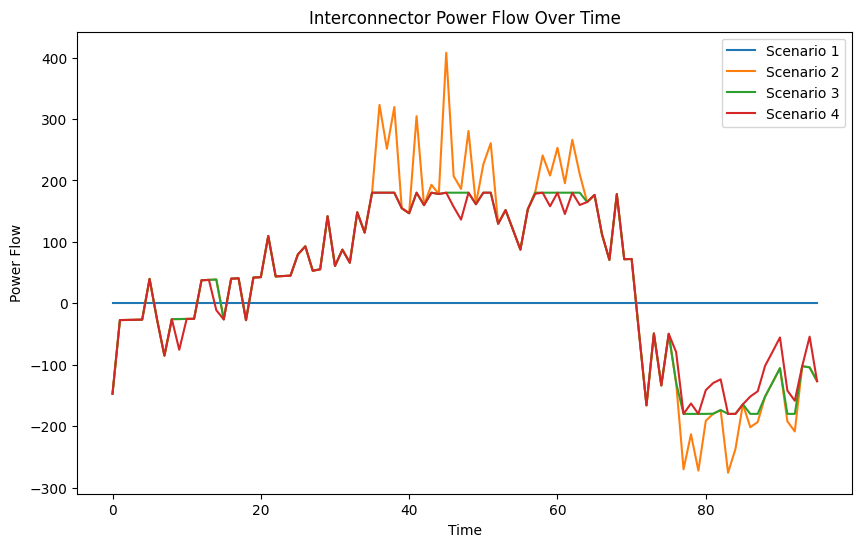

In [15]:
# interconnector power flow over time in Scenarios 1-4

# solve model 
solver = pyomo.SolverFactory('gurobi')
flow_results = {}

for i, params in scenarios.items():
    model.Fmax = params['Fmax']
    model.K[0] = params['K']
    model.K[1] = params['K']

    solver.solve(model)
    flow_results[i] = [pyomo.value(model.F[t]) for t in model.T] 

# plot intercoonector power flow over time for each scenario
plt.figure(figsize=(10,6))
for i, params in scenarios.items():
    plt.plot(flow_results[i], label=f'Scenario {i}')
plt.xlabel('Time')
plt.ylabel('Power Flow')
plt.title('Interconnector Power Flow Over Time')
plt.legend()
plt.show()


## Q5

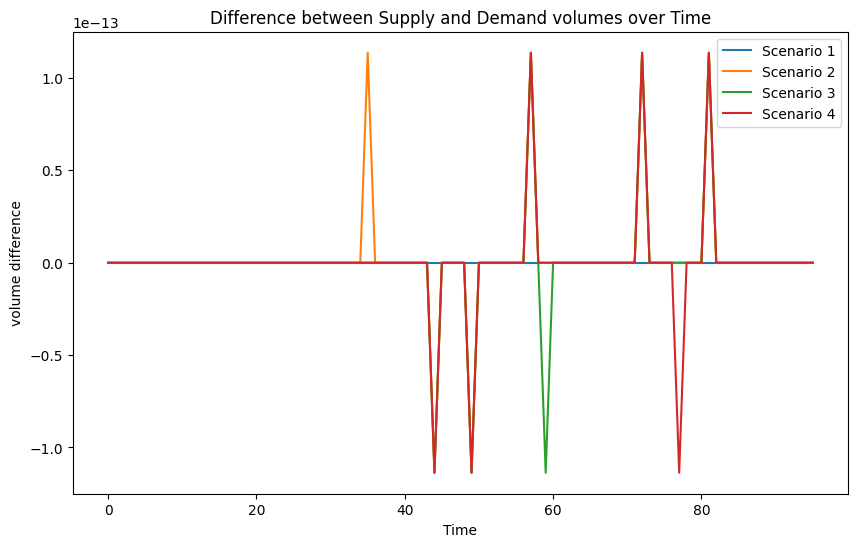

In [35]:
# electricity price and supply and demand volumes in each area over time in Scenarios 1-4

# solve model 
solver = pyomo.SolverFactory('gurobi')
electricity_results = {}
supply_results = {}
demand_results = {}

for i, params in scenarios.items():
        model.Fmax = params['Fmax']
        model.K[0] = params['K']
        model.K[1] = params['K']

        solver.solve(model)
        #electricity_results[Z][i] = [pyomo.value(model.F[t]) for t in model.T]
        supply_results[i] = [pyomo.value(model.S[0,t]) + pyomo.value(model.S[1,t]) for t in model.T]
        demand_results[i] = [pyomo.value(model.D[0,t]) + pyomo.value(model.D[1,t]) for t in model.T]  

# plot electricity price in each area over time for each scenario
#plt.figure(figsize=(10,6))
#for i, params in scenarios.items():
    #for Z in model.Z:
        #plt.plot(electricity_results[Z][i], label=f'Area {Z}, Scenario {i}')
#plt.xlabel('Time')
#plt.ylabel('Electricity price')
#plt.title('Electricity prices in each area over time')
#plt.legend()
#plt.show()

# electricity price calculations
#for i, params in scenarios.items():
        #print(f'Minimum electricity price in scenario {i}: {min(electricity_results[i])}')
        #print(f'Average electricity price in scenario {i}: {np.mean(electricity_results[i])}')
        #print(f'Maximum electricity price in scenario {i}: {max(electricity_results[i])}')


# plot difference between supply and demand volumes over time for each scenario
plt.figure(figsize=(10,6))
for i, params in scenarios.items():
    plt.plot([s-d for s, d in zip(supply_results[i], demand_results[i])], label=f'Scenario {i}')
plt.xlabel('Time')
plt.ylabel('volume difference')
plt.title('Difference between Supply and Demand volumes over Time')
plt.legend()
plt.show()
